# Ingredient Scanner: Person 1 (Data + NLP) pipeline

*NLP-Based Detection and Interpretation of Hidden Food Ingredients*

This notebook walks through the whole data foundation, stage by stage. It uses the code in `src/`;
nothing here is a separate implementation, so the notebook and the scripts always agree.

| Stage | Section |
|---|---|
| 1 | Dataset source and download |
| 2 | Filtering into a project dataset |
| 3 | Exploratory data analysis |
| 4 | Preprocessing (`process_ingredient_text`) |
| 5 | Entity schema |
| 6 | Weak labelling (dictionaries + rules) |
| 7 | Silver dataset and validation checks |
| 8 | Leakage-free train / validation / test split |
| 9 | Gold annotation workflow |
| 10 | Dictionary baseline and evaluation |
| 11 | Error analysis |
| 12 | Integration with Person 2 and Person 3 |
| 13 | Final processed CSV |
| 14 | Limitations |

**SILVER data** = generated automatically by rules. **GOLD data** = checked by a human. At the time
this notebook was executed, **no gold annotations exist yet**. Every result that needs gold says so
explicitly instead of showing invented numbers.

By default the notebook reads the outputs of `python run_pipeline.py`. Set `RUN_FULL_PIPELINE = True`
to regenerate everything (about 3 minutes; the 1.3 GB raw download is never repeated automatically).

In [1]:
import os, sys, json
from pathlib import Path

# make the project root the working directory, whether the notebook is started from notebooks/ or the root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, Markdown, HTML, display
pd.set_option("display.max_colwidth", 120)

RUN_FULL_PIPELINE = False
if RUN_FULL_PIPELINE:
    import run_pipeline
    for step in run_pipeline.STEPS:
        run_pipeline.run(step)

def show_json(path, keys=None):
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    return {k: data[k] for k in keys} if keys else data

print("Project root:", ROOT.name)

Project root: ingredient-scanner


## 1. Dataset source and download

**Source:** the official Open Food Facts full CSV export (`en.openfoodfacts.org.products.csv.gz`, ODbL licence).
`src/data/download_dataset.py` tries the official URL first, then OFF's official AWS S3 mirror. It records
URL, date, size and SHA-256 in a manifest, because the database changes every day.

We do **not** use the search API: it is rate-limited and meant for apps. From the ~200 columns we only read 10.

In [2]:
display(show_json("data/raw/download_manifest.json"))
profile = show_json("reports/source_profile.json")
print(f"Products in the full export: {profile['total_products']:,}")
pd.Series(profile["missing_percent"], name="% missing in the full export").to_frame()

{'url': 'https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz',
 'downloaded_at_utc': '2026-10-01T18:01:36+00:00',
 'size_bytes': 1275171186,
 'sha256': 'f72687ee8bc6522054fe69dbfda6b91902c16af1ec2e043cde27bc6c29ad8176',
 'license': 'Open Database License (ODbL) - attribution to Open Food Facts contributors required'}

Products in the full export: 4,535,553


,% missing in the full export
code,0.00
product_name,7.41
brands,37.11
countries_en,0.50
categories_en,59.77
main_category_en,59.78
ingredients_text,72.40
ingredients_tags,71.67
additives_n,71.60
additives_tags,84.54


> **WHAT WE DID:** Downloaded the full Open Food Facts export once and profiled all 4.5 million products.
>
> **WHY:** We need a public, citable, realistic source of real ingredient lists. Profiling the whole source tells us what is usable (72% of products have no ingredient text).
>
> **INPUT:** The official 1.3 GB gzip CSV export.
>
> **OUTPUT:** `data/raw/...csv.gz` (not in git), `download_manifest.json`, `reports/source_profile.json`.
>
> **HOW PERSON 2 USES IT:** Nothing directly; it is the origin of every training sentence.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"We used the official bulk export instead of the rate-limited API, read only the 10 columns we need, and recorded a checksum because Open Food Facts changes daily."*

## 2. Filtering into a manageable project dataset

`src/data/filter_dataset.py` streams the export in chunks of 200,000 rows and applies explicit, logged filters.

In [3]:
log = show_json("reports/filter_log.json")
funnel = pd.DataFrame([{"step": "Full export", "products": profile["total_products"]}] + log["funnel"])
display(funnel)
print("Final market groups:", log["final_country_groups"])
print("Language rule used:", log["final_english_rule"])
products = pd.read_csv("data/processed/products.csv", dtype={"product_id": str})
products[["product_id", "product_name", "country_group", "ingredients_text_raw"]].sample(5, random_state=3)

,step,products
0,Full export,4535553
1,in English-speaking country groups,1441888
2,unique barcode,1441883
3,has ingredients_text (not empty / 'undefined'),531903
4,length 3-1500 chars,528982
5,English ingredient list,509294
6,unique ingredient list (exact duplicates removed),405812
7,after per-country-group sampling,22355


Final market groups: {'uk_ireland': 7000, 'north_america': 7000, 'india': 4355, 'other_english': 4000}
Language rule used: {'marker_words': 21500, 'assumed_ascii_no_markers': 855}


,product_id,product_name,country_group,ingredients_text_raw
18421,8906024484142,badam flavored milk,india,"Milk Solids, Sugar & Water. Contains Permitted Synthetic Food Colours (INS 102 & INS 110) And Added Nature-identical..."
2165,0041303009093,"Premium lemonade, lemonade",north_america,"Filtered water, sweeteners (high fructose corn syrup and sugar), lemon juice from concentrate, natural flavors, asco..."
5114,0194346198818,Broccoli Cheddar Quiche,north_america,KKDU RD on 08/15/20 SAVE $2.71 MKS BROC QUICHE 8&quot; IS $8. L/KA YOU PAY! $8.13 MARKETSIDE BROCCOLI CHEDDA QUICHE ...
16041,8901030825545,Horlicks Protein Plus Vanilla Flavour,india,"Skimmed Milk Powder [(50%) of which Casein (14%)], Protein Products (21%) [Whey Protein Concentrate (15%), Soy Prote..."
14764,6009811550562,Lean Sticks Buddy Pack 100% Beef,other_english,"Beef, Black pepper, Caramel, Cloves, Dextrose, Flavouring, Food Colour, Molasses, preservatives (_Sulphur Dioxide_, ..."


> **WHAT WE DID:** Kept products sold in English-speaking markets with a real, English ingredient list, removed duplicates and placeholders (36k+ lists are literally 'undefined'), then sampled a fixed number per market with seed 42.
>
> **WHY:** Indian labels write 'INS 330' or '(330)', UK labels 'E330', US labels names such as 'Red 40'. Mixing markets teaches every notation. India is kept completely because it is the smallest and most important group.
>
> **INPUT:** The raw export.
>
> **OUTPUT:** `data/processed/products.csv`: 22,355 products. The original text is kept unchanged in `ingredients_text_raw`.
>
> **HOW PERSON 2 USES IT:** Every silver/gold record is one of these products.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Our filters are explicit and logged as a funnel. The language filter is a keyword heuristic we can explain in one sentence, and re-running the script reproduces the identical file."*

## 3. Exploratory data analysis

`src/data/eda.py` → `reports/dataset_statistics.md`

Characters per list: {'mean': 287.8, '50%': 230.0, 'min': 3.0, 'max': 1497.0}
Exact-duplicate lists removed: 103482
Products with >=1 additive (OFF detection): 64.9 %
How additive codes are written, by market (% of products):


,E-number (E330),INS number (INS 330),bare number (330),no code
india,6.4,27.7,14.0,51.9
uk_ireland,9.2,0.1,0.9,89.8
north_america,0.5,0.0,0.2,99.3
other_english,7.3,1.1,27.3,64.2


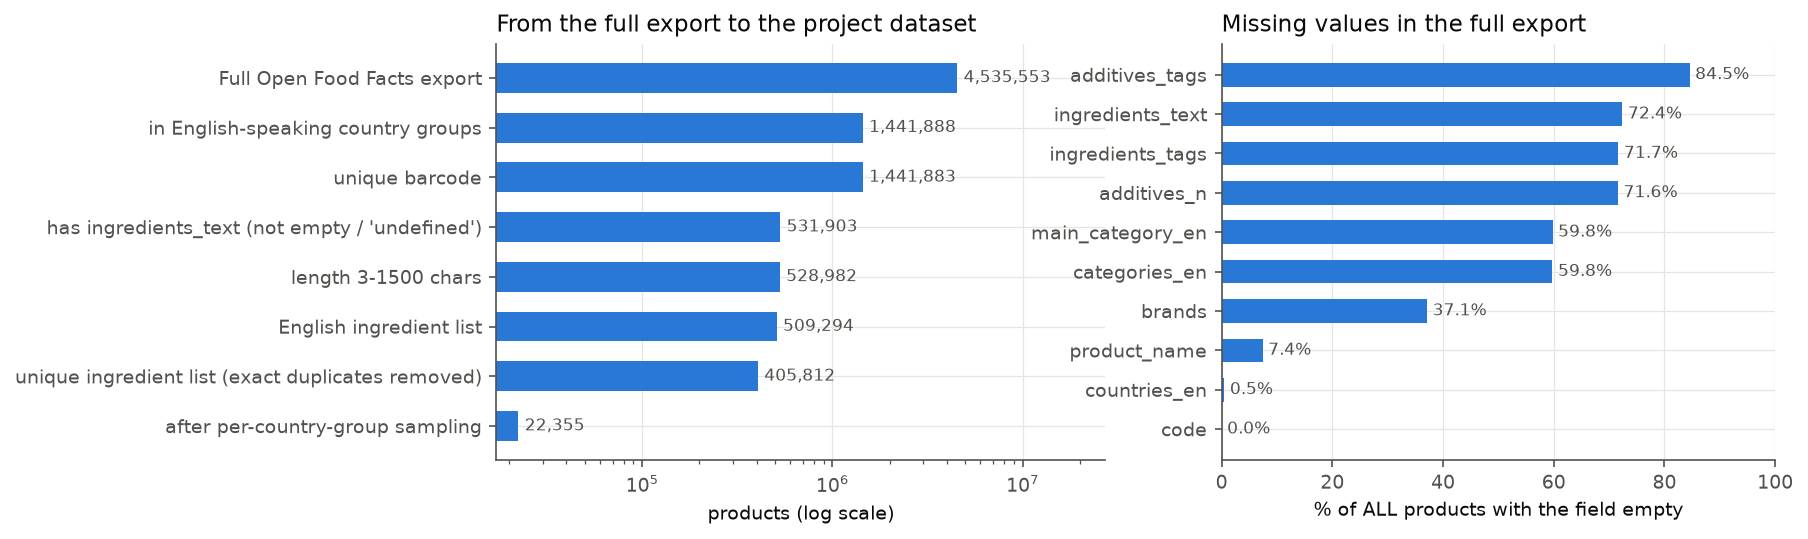

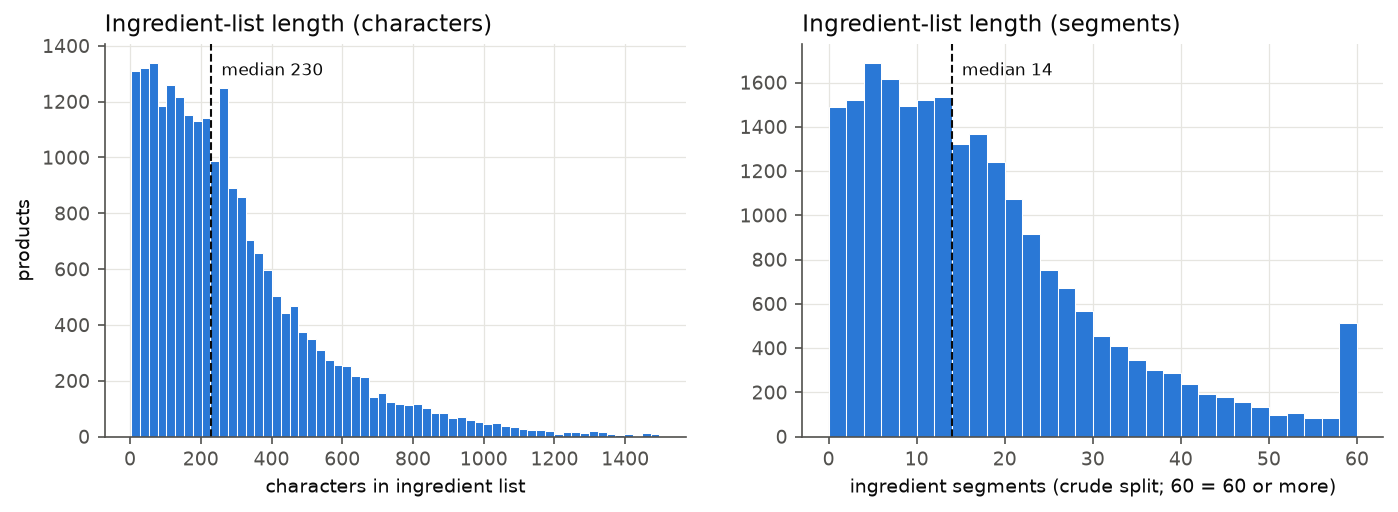

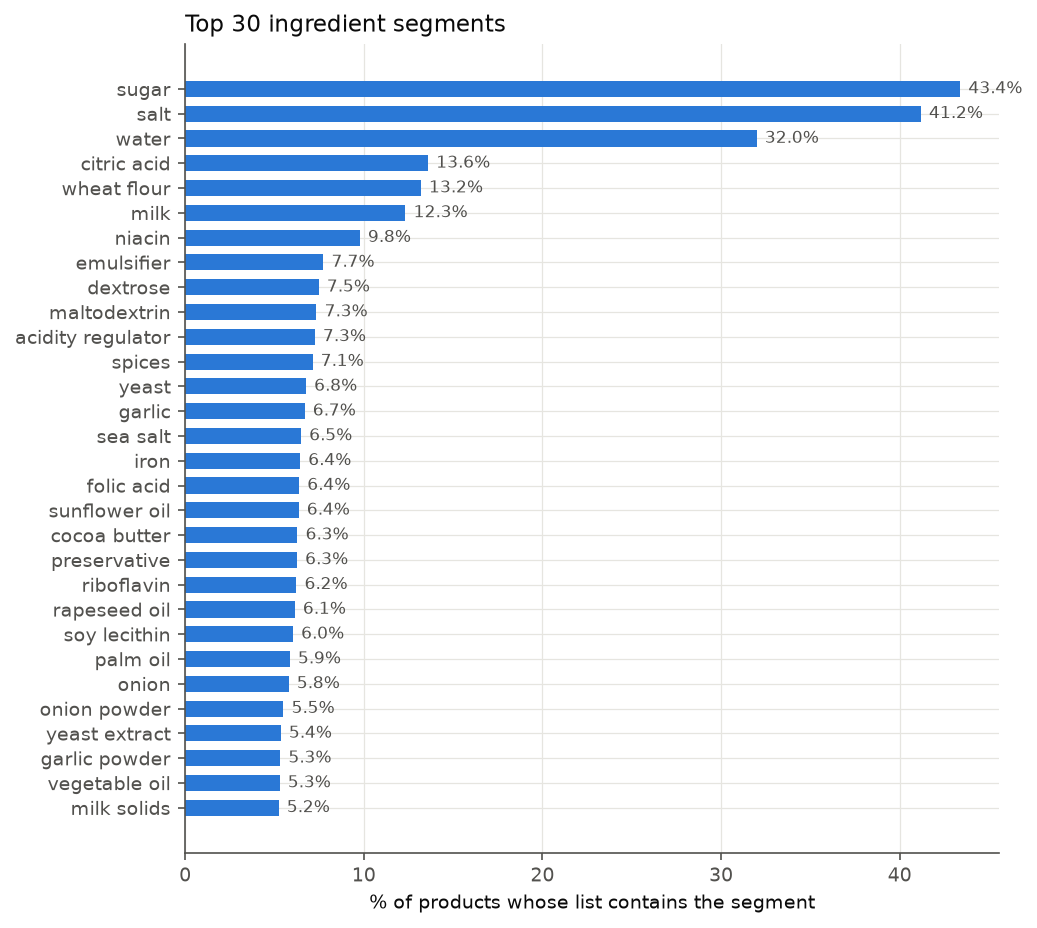

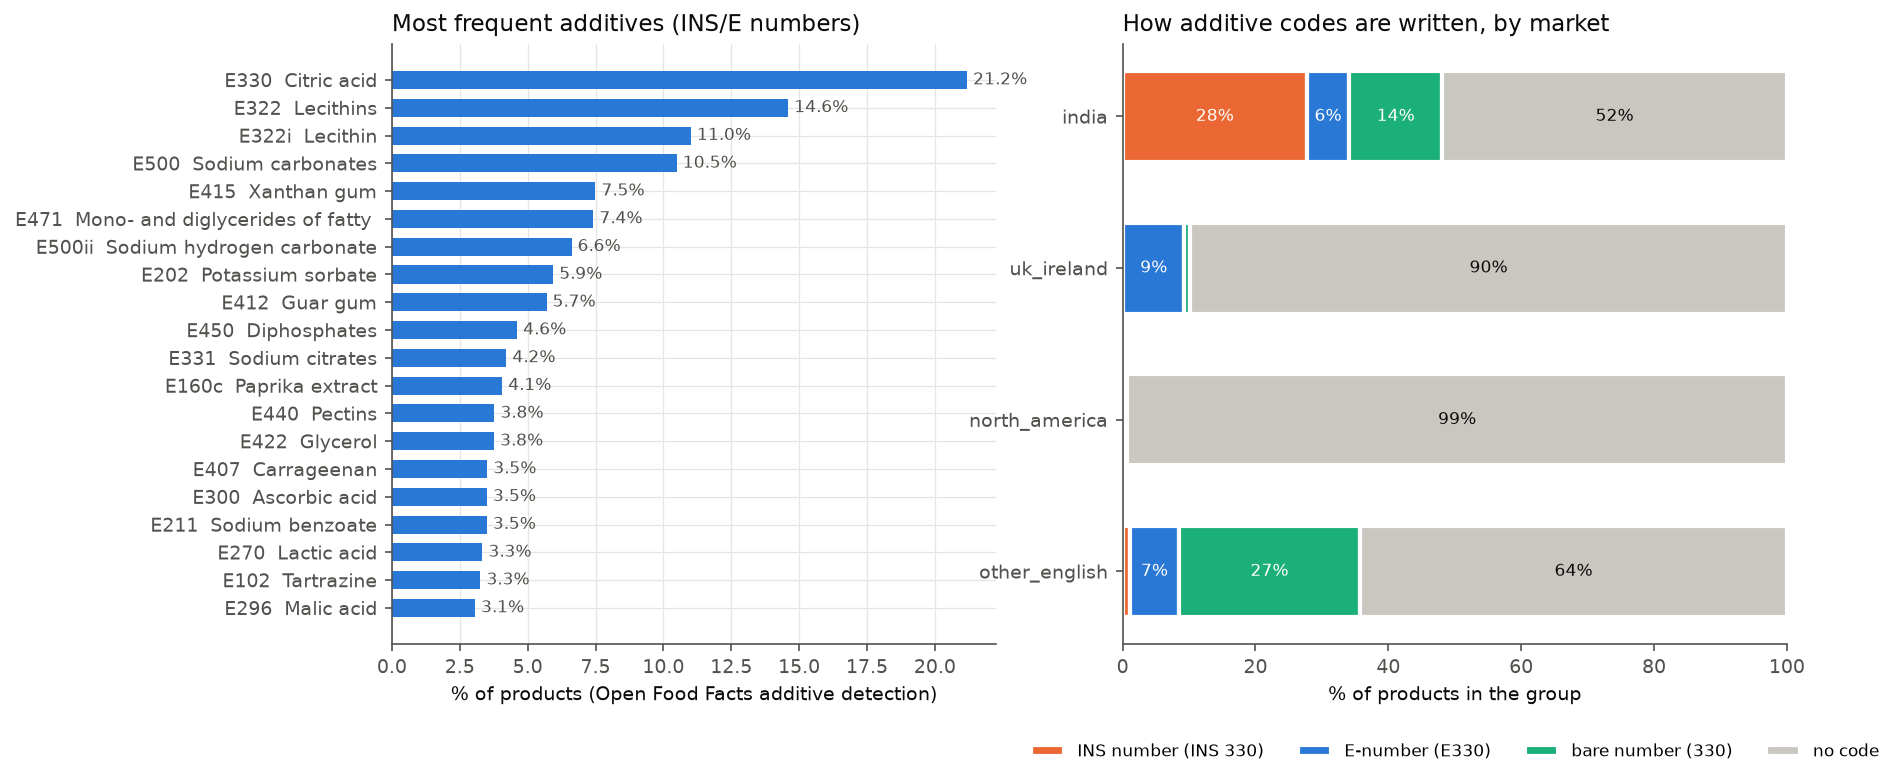

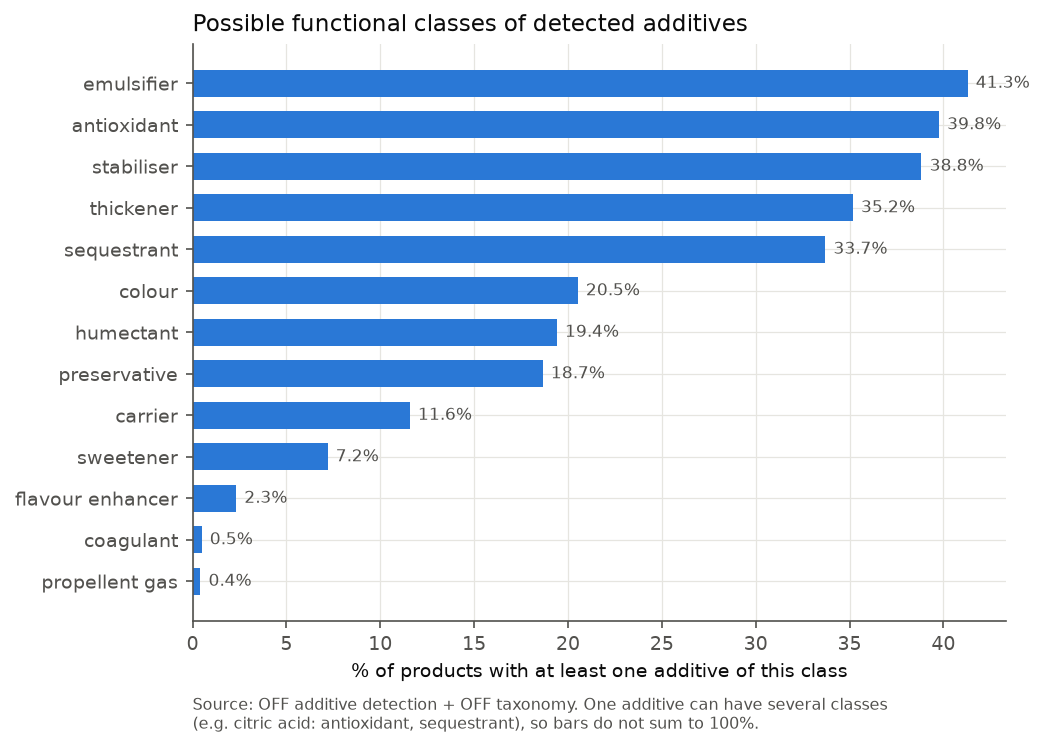

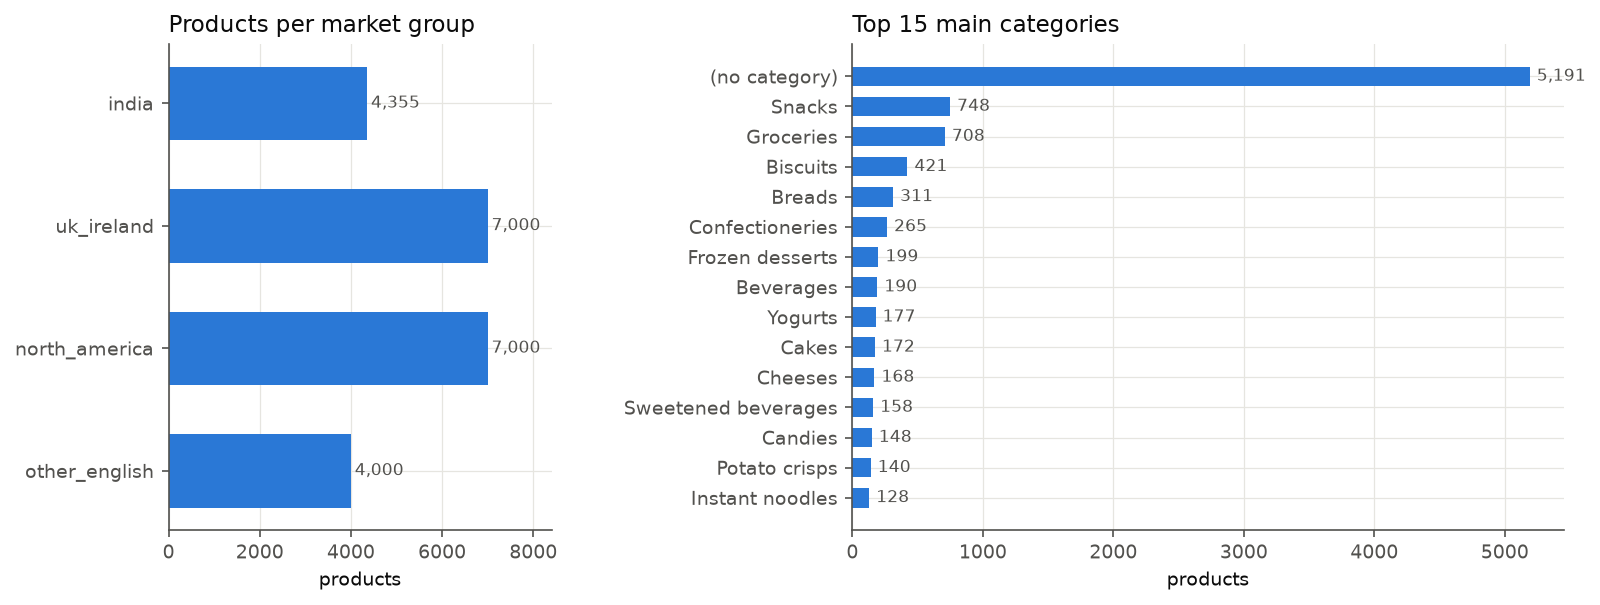

In [4]:
stats = show_json("reports/dataset_statistics.json")
print("Characters per list:", {k: stats["chars"][k] for k in ("mean", "50%", "min", "max")})
print("Exact-duplicate lists removed:", stats["exact_duplicate_lists_removed"])
print("Products with >=1 additive (OFF detection):", stats["percent_with_additive_off"], "%")
print("How additive codes are written, by market (% of products):")
display(pd.DataFrame(stats["percent_with_code_style_by_group"]).T)
for fig in ["01_dataset_size_and_missingness", "02_ingredient_length_distribution", "03_top_ingredient_terms",
            "04_additive_code_frequency", "05_additive_function_classes", "06_market_groups_and_categories"]:
    display(Image(f"reports/figures/{fig}.png", width=850))

> **WHAT WE DID:** Measured size, missingness, length, duplicates, frequent ingredients, frequent INS/E codes, additive classes and categories.
>
> **WHY:** The analysis justifies design decisions: the long tail of lengths (truncation), notation differences between markets (sampling), and how often additives occur (class balance).
>
> **INPUT:** `products.csv`, the source profile and the OFF additive taxonomy.
>
> **OUTPUT:** Six figures in `reports/figures/` and `reports/dataset_statistics.md`.
>
> **HOW PERSON 2 USES IT:** Shows him the class imbalance and the length distribution before training.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"42% of Indian products write additive codes compared with under 1% in North America, so an India-only or US-only dataset would miss notations the OCR pipeline will see."*

## 4. Preprocessing: `process_ingredient_text(text)`

One function for **any** text: Open Food Facts lists, OCR output from Person 3, or typed text.
Principle: **remove only what carries no meaning**. Numbers, punctuation and codes stay, because "INS 330" is an entity.

In [5]:
from src.preprocessing.pipeline import process_ingredient_text

ocr_like = "REFINED WHEAT FLOUR (MAIDA), SUGAR (20.7%), _Milk_ Solids,, RAISING AGENTS [503(ii), 500(ii)]\nemulsi-\nfier (INS No. 322), Acidity Regulator &amp; E 330"
result = process_ingredient_text(ocr_like)
print("RAW       :", repr(result["raw_text"]))
print("NORMALISED:", result["text"])
print("TOKENS    :", result["tokens"])
display(pd.DataFrame(result["segments"]).rename(columns={"depth": "bracket depth"}))
display(pd.DataFrame(result["additive_codes"]))
display(pd.DataFrame(result["percentages"]))

RAW       : 'REFINED WHEAT FLOUR (MAIDA), SUGAR (20.7%), _Milk_ Solids,, RAISING AGENTS [503(ii), 500(ii)]\nemulsi-\nfier (INS No. 322), Acidity Regulator &amp; E 330'
NORMALISED: REFINED WHEAT FLOUR (MAIDA), SUGAR (20.7%), Milk Solids, RAISING AGENTS [503(ii), 500(ii)] emulsifier (INS No. 322), Acidity Regulator & E 330
TOKENS    : ['REFINED', 'WHEAT', 'FLOUR', '(', 'MAIDA', ')', ',', 'SUGAR', '(', '20.7%', ')', ',', 'Milk', 'Solids', ',', 'RAISING', 'AGENTS', '[', '503', '(', 'ii', ')', ',', '500', '(', 'ii', ')', ']', 'emulsifier', '(', 'INS', 'No', '.', '322', ')', ',', 'Acidity', 'Regulator', '&', 'E', '330']


,start,end,text,bracket depth
0,0,19,REFINED WHEAT FLOUR,0
1,21,26,MAIDA,1
2,29,34,SUGAR,0
3,36,41,20.7%,1
4,44,55,Milk Solids,0
5,57,71,RAISING AGENTS,0
6,73,80,503(ii),1
7,82,89,500(ii),1
8,91,101,emulsifier,0
9,103,114,INS No. 322,1


,start,end,text,number,style
0,73,80,503(ii),503ii,bare
1,82,89,500(ii),500ii,bare
2,103,114,INS No. 322,322,INS
3,137,142,E 330,330,E


,value,start,end,text
0,20.7,36,41,20.7%


What happened to the example:
* `_Milk_` → `Milk` (Open Food Facts allergen markup), `&amp;` → `&` (HTML entity), `,,` → `,`
* `emulsi-` + line break + `fier` → `emulsifier` (OCR line-break hyphenation)
* case, numbers, brackets and **all four code notations** (`503(ii)`, `500(ii)`, `INS No. 322`, `E 330`) are kept
* codes are normalised to one canonical number for linking (`503(ii)` → `503ii`), but the text itself is not rewritten

> **WHAT WE DID:** Built normalisation (Unicode NFKC, HTML entities, markup, whitespace, OCR hyphenation), word tokenisation with character offsets, segmentation into (nested) ingredients, percentage extraction and INS/E-number detection and normalisation.
>
> **WHY:** Raw label text is messy and comes in many notations. The model and the rules need one consistent form, but blind cleaning would destroy entities such as 'INS 330'.
>
> **INPUT:** Any string.
>
> **OUTPUT:** A dict with raw text, normalised text, tokens + offsets, segments, additive codes, percentages.
>
> **HOW PERSON 2 USES IT:** His tokens and labels are defined on exactly this normalised text and tokenisation.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"We never overwrite the original text. Normalisation only unifies characters and spacing, and additive codes are detected before segmentation so brackets in '503(ii)' are not mistaken for ingredient brackets."*

## 5. Entity schema (10 labels)

Full guideline with examples and overlap rules: [`reports/entity_schema.md`](../reports/entity_schema.md).

In [6]:
from src.labeling.bio import LABELS, LABEL2ID
schema = pd.DataFrame({
    "label": LABELS,
    "examples": ["sugar, glucose syrup, honey", "sucralose, sorbitol, stevia", "palm oil, ghee, cocoa butter",
                 "sodium benzoate, potassium sorbate", "tartrazine, caramel colour, Red 40",
                 "citric acid, soy lecithin, xanthan gum", "INS 330, E330, (471), 503(ii)",
                 "acidity regulator, emulsifier, colour", "natural flavour, vanillin", "wheat flour, salt, milk solids"]})
display(schema)
print(f"{len(LABEL2ID)} BIO tags:", list(LABEL2ID)[:7], "...")

,label,examples
0,SUGAR,"sugar, glucose syrup, honey"
1,SWEETENER,"sucralose, sorbitol, stevia"
2,FAT,"palm oil, ghee, cocoa butter"
3,PRESERVATIVE,"sodium benzoate, potassium sorbate"
4,COLOUR,"tartrazine, caramel colour, Red 40"
5,ADDITIVE,"citric acid, soy lecithin, xanthan gum"
6,INS_CODE,"INS 330, E330, (471), 503(ii)"
7,FUNCTION_CLASS,"acidity regulator, emulsifier, colour"
8,FLAVOURING,"natural flavour, vanillin"
9,INGREDIENT,"wheat flour, salt, milk solids"


21 BIO tags: ['O', 'B-SUGAR', 'I-SUGAR', 'B-SWEETENER', 'I-SWEETENER', 'B-FAT', 'I-FAT'] ...


> **WHAT WE DID:** Defined 10 mutually exclusive labels, with PRESERVATIVE and COLOUR as their own classes, plus a priority rule for overlaps and written decisions for ambiguous terms.
>
> **WHY:** Without one written policy three annotators label 'citric acid' or 'Colour (150d)' differently, and the model learns noise. A named substance's label follows its INS number (100-199 colours, 200-299 preservatives with listed exceptions), which is checkable.
>
> **INPUT:** The project goal and the label conventions found in the data.
>
> **OUTPUT:** `reports/entity_schema.md`, `configs/lexicons/additive_label_rules.yaml`, `label2id.json`.
>
> **HOW PERSON 2 USES IT:** The 21 BIO tags are his model's output classes.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Each span has exactly one label. The INS numbering system groups additives by function, so we use it to separate preservatives and colours from other additives, and the exceptions are listed explicitly."*

## 6. Weak labelling: dictionaries + regex + rules

`src/labeling/weak_labeler.py` applies a fixed decision order:

0. skip allergen statements, storage and contact text, claims
1. INS/E codes (regex) → `INS_CODE`
2. split into segments, cut out codes, strip framing ("contains less than 2% of", "20%")
3. the whole piece is a dictionary term → its label
4. several terms joined by and/&/or → one entity each
5. several dictionary terms covering the piece ("Emulsifier soy lecithin")
6. the piece **ends** with a dictionary term or head word ("organic cane **sugar**", "refined palm **oil**")
7. fallback: a short piece of words seen in ≥3 products → `INGREDIENT`

Dictionaries: hand-curated lists and aliases (`configs/lexicons/`) plus names from the Open Food Facts additive taxonomy (counts printed below).

In [7]:
from src.labeling.weak_labeler import label_text
from src.labeling.interpret import interpret_entities, describe
from src.labeling.lexicon import load_lexicon
from collections import Counter

COLOURS = {"SUGAR": "#eb6834", "SWEETENER": "#e87ba4", "FAT": "#eda100", "PRESERVATIVE": "#e34948",
           "COLOUR": "#4a3aa7", "ADDITIVE": "#2a78d6", "INS_CODE": "#1baf7a", "FUNCTION_CLASS": "#52514e",
           "FLAVOURING": "#008300", "INGREDIENT": "#898781"}

def highlight(text, entities):
    html, pos = [], 0
    for e in entities:
        html.append(text[pos:e["start"]])
        html.append(f'<span style="background:{COLOURS[e["label"]]};color:white;padding:1px 4px;border-radius:4px">'
                    f'{text[e["start"]:e["end"]]} <sub>{e["label"]}</sub></span>')
        pos = e["end"]
    html.append(text[pos:])
    return HTML('<div style="line-height:2.1;font-family:sans-serif">' + "".join(html) + "</div>")

print("Lexicon entries per label :", dict(Counter(e.label for e in load_lexicon().values())))
print("Lexicon entries per source:", dict(Counter(e.source for e in load_lexicon().values())))
examples = [
    "Sugar, glucose syrup, INS 330, palm oil",
    "Milk solids, sugar, emulsifier (471), stabilizers (407, 466), artificial flavouring substances (vanilla), Permitted synthetic food colours (102, 110). May contain traces of nuts.",
    "CARBONATED WATER, NATURAL FLAVOR, CITRIC ACID, POTASSIUM BENZOATE AND POTASSIUM SORBATE (PRESERVATIVES), SUCRALOSE, RED 40",
    "Organic cane sugar, peanut butter, refined palmolein oil, cocoa butter, maltitol syrup, contains less than 2% of: salt, caramel color",
]
for text in examples:
    r = label_text(text)
    display(highlight(r["text"], r["entities"]))

Lexicon entries per label : {'SWEETENER': 76, 'SUGAR': 64, 'FAT': 22, 'FLAVOURING': 16, 'FUNCTION_CLASS': 117, 'ADDITIVE': 896, 'COLOUR': 263, 'PRESERVATIVE': 102}
Lexicon entries per source: {'dict:sweeteners': 34, 'dict:sugars': 64, 'dict:fats': 22, 'dict:flavourings': 16, 'dict:function_classes': 117, 'dict:additive_aliases': 143, 'dict:off_taxonomy': 1160}


In [8]:
# Each entity records WHICH rule produced it (used later to measure rule precision on gold data)
r = label_text(examples[2])
pd.DataFrame(r["entities"])[["text", "label", "rule", "number"]]

,text,label,rule,number
0,CARBONATED WATER,INGREDIENT,fallback:segment,NaN
1,NATURAL FLAVOR,FLAVOURING,head:flavour_word,NaN
2,CITRIC ACID,ADDITIVE,dict:additive_aliases,330
3,POTASSIUM BENZOATE,PRESERVATIVE,dict_conj:additive_aliases,212
4,POTASSIUM SORBATE,PRESERVATIVE,dict_conj:additive_aliases,202
5,PRESERVATIVES,FUNCTION_CLASS,dict:function_classes,NaN
6,SUCRALOSE,SWEETENER,dict:sweeteners,955
7,RED 40,COLOUR,dict:additive_aliases,129


In [9]:
# Interpretation layer (identification -> interpretation; never a health claim)
r = label_text("Acidity regulator (INS 330), Emulsifiers (471, soy lecithin), potassium sorbate (preservative), Colour (150d)")
for e in interpret_entities(r["text"], r["entities"]):
    if e["label"] != "FUNCTION_CLASS":
        print(f"{e['label']:13} {describe(e)}")

INS_CODE      INS 330 -> Citric acid -> acidity regulator
INS_CODE      471 -> Mono- and diglycerides of fatty acids -> emulsifier
ADDITIVE      soy lecithin -> Lecithins -> emulsifier
PRESERVATIVE  potassium sorbate -> preservative
INS_CODE      150d -> Sulphite ammonia caramel -> colour


> **WHAT WE DID:** Built a reusable weak labeller that converts text into labelled spans using dictionaries, regular expressions and head-word rules, with every decision traceable to a rule.
>
> **WHY:** We cannot hand-label 22,000 products. Rules give a large, cheap, consistent (but imperfect) training set.
>
> **INPUT:** Normalised text from `process_ingredient_text`.
>
> **OUTPUT:** Entity spans with label, rule name and (for additives) the INS number.
>
> **HOW PERSON 2 USES IT:** His training labels come from this labeller (silver data).
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Silver labels are automatically generated labels produced using dictionaries and rules. They are useful as a large training resource, but they are not treated as ground truth because the rules can make mistakes."*

## 7. Silver dataset and validation checks

`src/labeling/build_silver.py` → `data/processed/silver.jsonl.gz`

Records: 22,323   entities: 357,934   tokens: 1,400,780   skipped: {'mostly non-Latin script': 31, 'too many tokens': 1}


INGREDIENT        211986
ADDITIVE           32811
FUNCTION_CLASS     25516
SUGAR              24983
FAT                20336
INS_CODE           17643
FLAVOURING         13485
COLOUR              5492
PRESERVATIVE        3397
SWEETENER           2285
Name: silver entities, dtype: int64

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
token,Maida,",",sugar,",",edible,veg,fat,",",salt,",",milk,solids,",",yeast,",",vanilla,powder,",",improvers
BIO tag,B-INGREDIENT,O,B-SUGAR,O,B-FAT,I-FAT,I-FAT,O,B-INGREDIENT,O,B-INGREDIENT,I-INGREDIENT,O,B-INGREDIENT,O,B-INGREDIENT,I-INGREDIENT,O,B-FUNCTION_CLASS


confidence of first entity: None <- null until measured on gold (never invented)


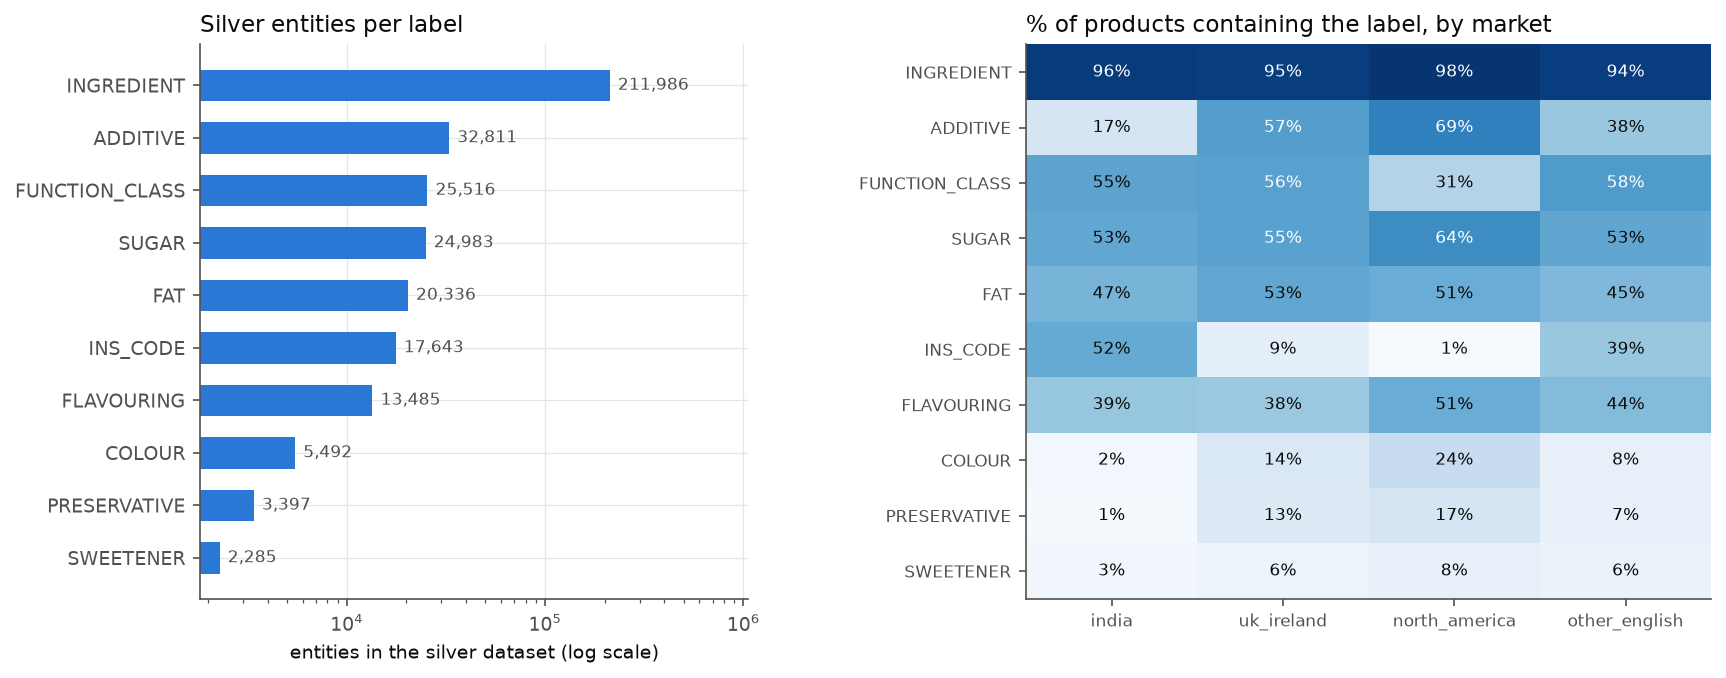

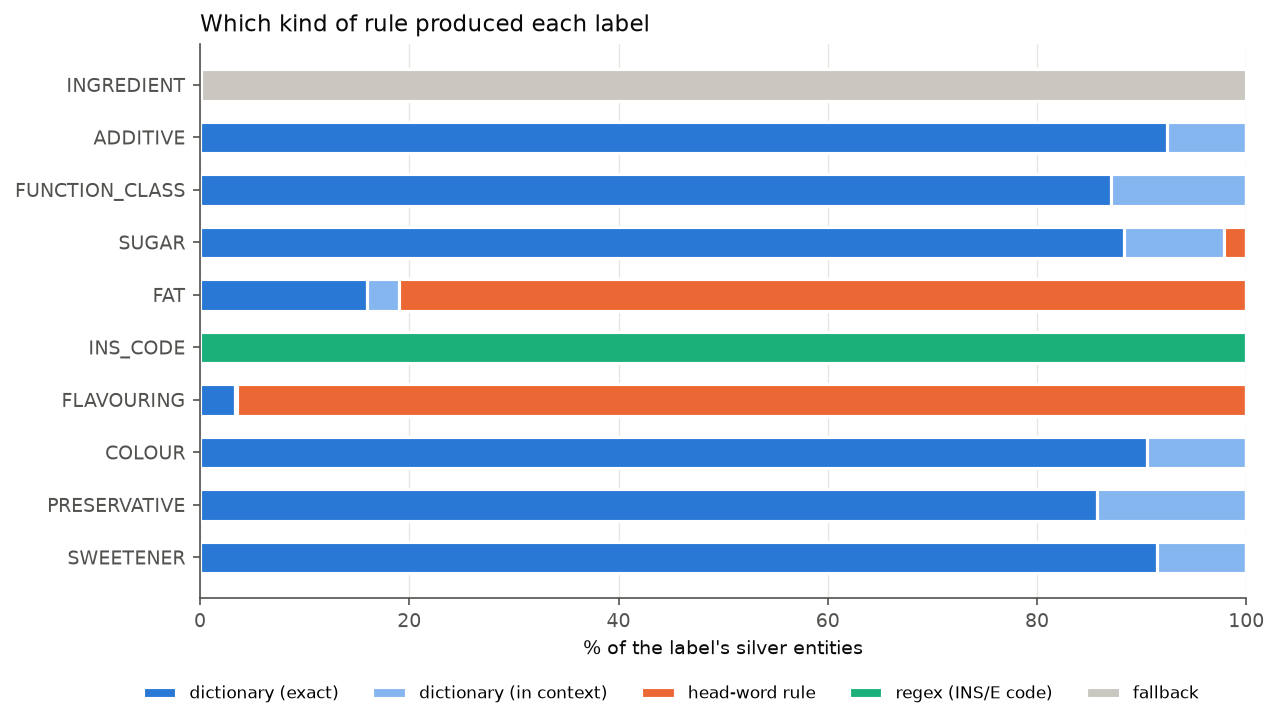

In [10]:
from src.utils.io import read_jsonl
silver = read_jsonl("data/processed/silver.jsonl.gz")
slog = show_json("reports/silver_log.json")
print(f"Records: {slog['records_out']:,}   entities: {slog['entities']:,}   tokens: {slog['tokens']:,}   skipped: {slog['skipped']}")
display(pd.Series(slog["entities_per_label"], name="silver entities"))
example = next(r for r in silver if r["country_group"] == "india" and 8 < len(r["tokens"]) < 30)
display(pd.DataFrame({"token": example["tokens"], "BIO tag": example["ner_tags"]}).T)
print("confidence of first entity:", example["entities"][0]["confidence"], "<- null until measured on gold (never invented)")
display(Image("reports/figures/07_entity_label_distribution.png", width=900))
display(Image("reports/figures/08_label_sources.png", width=750))

In [11]:
# The pipeline FAILS LOUDLY on malformed data. Here we break a record on purpose:
from src.utils.validation import validate_records, DataValidationError
broken = dict(example, id="broken-example", ner_tags=["I-SUGAR"] + example["ner_tags"][1:-1])  # bad BIO + wrong length
try:
    validate_records([broken], name="demo")
except DataValidationError as err:
    print("DataValidationError:", err)
report = validate_records(silver, name="silver")
print(f"\nAll {report['records']:,} silver records passed: {len(report['problems'])} problems")

DataValidationError: demo: 2 problem(s), first ones:
  [broken-example] length mismatch: 19 tokens, 18 tags, 19 offsets
  [broken-example] I-SUGAR at position 0 follows O



All 22,323 silver records passed: 0 problems


> **WHAT WE DID:** Labelled all products, converted spans to BIO tags, and validated every record (lengths, BIO sequences, offsets, labels, duplicates, length limits, control characters).
>
> **WHY:** Malformed data silently ruins training. A failing check is better than a wrong model.
>
> **INPUT:** `products.csv` + the weak labeller.
>
> **OUTPUT:** `silver.jsonl.gz` (22,323 records, ~358k entities) with original text, normalised text, tokens, offsets, BIO tags, entities with rule source.
>
> **HOW PERSON 2 USES IT:** This is his training corpus.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Entities are stored as character spans and converted to one BIO tag per token. If an entity boundary cuts through a token, the conversion raises an error, and that check caught two real bugs (decimal commas and decimal points) during development."*

## 8. Leakage-free train / validation / test split

`src/data/split_dataset.py`

In [12]:
split_report = show_json("reports/split_report.json")
print("Groups:", split_report["groups"], "| groups with >1 product:", split_report["groups_with_more_than_one_product"])
print("Split sizes:", split_report["silver_split_sizes"], split_report["silver_split_percent"])
print("Leakage check:", split_report["leakage_check"])
pd.DataFrame(split_report["market_mix_percent"]).T

Groups: 20087 | groups with >1 product: 1050
Split sizes: {'train': 15556, 'validation': 3280, 'test': 3487} {'train': 69.7, 'validation': 14.7, 'test': 15.6}
Leakage check: {'description': 'max Jaccard similarity of ingredient-segment sets between each val/test product and its most similar train product', 'median': 0.3, 'share_at_least_0.8': 0.0015, 'share_identical_1.0': 0.0}


,india,north_america,other_english,uk_ireland
test,18.6,30.1,17.2,34.1
train,19.5,31.5,17.9,31.1
validation,20.2,32.0,18.2,29.5


> **WHAT WE DID:** Grouped similar products (same letters, same ingredient set, same name+brand, same first 5 ingredients, or Jaccard >= 0.8) with union-find and assigned whole groups to 70/15/15 splits per market, seed 42.
>
> **WHY:** A random split would put near-identical recipes (two flavours of one gummy) into both train and test and inflate the test score.
>
> **INPUT:** `silver.jsonl.gz` and product metadata.
>
> **OUTPUT:** `data/splits/silver/*.jsonl.gz`, `split_assignment.csv`, `label2id.json`, `id2label.json`, `split_report.json`.
>
> **HOW PERSON 2 USES IT:** He trains on silver train and reports results only on gold test, both drawn from this assignment.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"We split by groups, not by products. After the split we measured leakage: only 0.15% of test products have a training product with at least 80% the same ingredients, and none are identical."*

## 9. Gold annotation workflow

**Tool:** [Doccano](https://github.com/doccano/doccano) (free, runs locally, span annotation, imports our JSONL).

1. `pip install doccano` (or Docker), `doccano init`, `doccano createuser`, `doccano webserver` + `doccano task`
2. Create a *Sequence Labeling* project, import the labels from `data/annotations/doccano_label_config.json`
3. Import `data/annotations/batches/<annotator>.jsonl` (pre-annotated with silver labels)
4. Check and correct **every** entity following `reports/entity_schema.md`, then mark the document approved
5. Export (JSONL, *only approved*) to `data/annotations/exports/<annotator>.jsonl`
6. `python -m src.annotation.agreement` (agreement items), resolve disagreements in `exports/adjudicated.jsonl`
7. `python -m src.annotation.import_annotations` → `gold_verified.jsonl` + `data/splits/gold/`

In [13]:
tracking = pd.read_csv("data/annotations/annotation_tracking.csv", dtype={"product_id": str})
print("Products selected for gold annotation:", len(tracking))
display(pd.crosstab(tracking["selection_reason"], tracking["split"], margins=True))
display(tracking["assigned_to"].value_counts())
gold_path = Path("data/annotations/gold_verified.jsonl")
n_gold = len(read_jsonl(gold_path)) if gold_path.exists() else 0
print(f"\nHuman-verified GOLD records so far: {n_gold}")

Products selected for gold annotation: 400


split,test,train,validation,All
selection_reason,,,,
has_colour,10,18,5,33
has_ins_code,12,22,6,40
has_preservative,10,18,5,33
has_sweetener,10,18,5,33
multiple_fats,7,13,4,24
multiple_sugars,7,13,4,24
noisy_text,10,18,5,33
stratified_random,54,100,26,180
All,120,220,60,400


assigned_to
annotator_1    120
annotator_2    120
annotator_3    120
ALL             40
Name: count, dtype: int64


Human-verified GOLD records so far: 0


> **WHAT WE DID:** Selected 400 products (train 220 / validation 60 / test 120) from the already-split data: stratified by market and length, enriched with hard cases. Added 40 shared agreement items and exported pre-annotated Doccano files per annotator.
>
> **WHY:** Silver labels cannot measure their own quality. Only human-verified gold data gives honest Precision, Recall and F1. Enrichment ensures rare classes (sweetener, preservative) have enough test examples.
>
> **INPUT:** Silver records + split assignment.
>
> **OUTPUT:** `data/annotations/batches/*.jsonl`, `doccano_label_config.json`, `annotation_tracking.csv`. Gold = 0 until we annotate.
>
> **HOW PERSON 2 USES IT:** The gold test set is his final benchmark. Gold validation is for model selection.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Gold data is human verified. The files are pre-annotated to save time, but nothing becomes gold until a person has approved it, and the import script refuses documents where annotators disagree until we adjudicate."*

## 10. Dictionary / rule baseline and evaluation

`src/baseline/dictionary_ner.py`, `src/evaluation/metrics.py`, `src/evaluation/evaluate_baseline.py`

In [14]:
from src.baseline.dictionary_ner import DictionaryNER
from src.evaluation.metrics import evaluate_entities, format_report

ner = DictionaryNER()
pred = ner.predict("Sugar, Acidity regulator (INS 330), refined palm oil")
print([(e["text"], e["label"]) for e in pred["entities"]])

gold_test = Path("data/splits/gold/test.jsonl")
if gold_test.exists():
    from src.evaluation.evaluate_baseline import load_gold_or_exit, predict_all
    gold = load_gold_or_exit("test")
    result = evaluate_entities([r["entities"] for r in gold], predict_all(gold))
    display(Markdown(format_report(result, f"Baseline on gold test ({len(gold)} products)")))
else:
    print("NO GOLD TEST SET YET -> baseline Precision/Recall/F1 are not reported.")
    print("Scoring the baseline against silver labels would be meaningless (silver = the baseline's own output).")

[('Sugar', 'SUGAR'), ('Acidity regulator', 'FUNCTION_CLASS'), ('INS 330', 'INS_CODE'), ('refined palm oil', 'FAT')]
NO GOLD TEST SET YET -> baseline Precision/Recall/F1 are not reported.
Scoring the baseline against silver labels would be meaningless (silver = the baseline's own output).


**How the scorer works** (strict entity level: span **and** label must match exactly). Illustrated on a
hand-written toy example, not project data:

In [15]:
toy_gold = [[{"start": 0, "end": 5, "label": "SUGAR"}, {"start": 7, "end": 15, "label": "FAT"}, {"start": 17, "end": 24, "label": "INS_CODE"}]]
toy_pred = [[{"start": 0, "end": 5, "label": "SUGAR"}, {"start": 7, "end": 15, "label": "INGREDIENT"}, {"start": 17, "end": 22, "label": "INS_CODE"}]]
display(Markdown(format_report(evaluate_entities(toy_gold, toy_pred), "Toy example")))

### Toy example

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| SUGAR | 1.000 | 1.000 | 1.000 | 1 |
| FAT | 0.000 | 0.000 | 0.000 | 1 |
| INS_CODE | 0.000 | 0.000 | 0.000 | 1 |
| INGREDIENT | 0.000 | 0.000 | 0.000 | 0 |
| **overall (micro)** | **0.333** | **0.333** | **0.333** | 3 |
| macro F1 | | | 0.333 | |
| partial match (micro) | 0.667 | 0.667 | 0.667 | |

### Evaluations that do not need gold data

**(a) Agreement with Open Food Facts' own additive parser** (product-level additive numbers, silver test split).
Not an accuracy measurement: OFF uses the same taxonomy names. It is useful for spotting gaps.

In [16]:
display(show_json("reports/off_additive_agreement.json", ["products", "agreement_precision", "agreement_recall", "agreement_f1",
                                                          "most_common_only_ours", "most_common_only_off"]))

{'products': 3487,
 'agreement_precision': 0.8509,
 'agreement_recall': 0.9124,
 'agreement_f1': 0.8806,
 'most_common_only_ours': {'170': 314,
  '14xx': 184,
  '300': 90,
  '339': 62,
  '508': 53,
  '160': 38,
  '509': 35,
  '341': 34,
  '551': 33,
  '471': 33,
  '500': 23,
  '220': 19,
  '516': 18,
  '301': 16,
  '331': 15},
 'most_common_only_off': {'428': 70,
  '160': 53,
  '471': 36,
  '330': 29,
  '460': 28,
  '500': 22,
  '472': 22,
  '100': 21,
  '541': 18,
  '450': 18,
  '322': 16,
  '150': 15,
  '452': 14,
  '412': 12,
  '14xx': 12}}

**(b) Robustness to OCR-like noise.** Characters are replaced by typical OCR confusions (l↔1, O↔0, S↔5 ...),
and predictions on noisy text are compared with predictions on clean text.

,all,INS_CODE,SUGAR,FAT,ADDITIVE
noise rate,,,,,
0.0,1.0000,1.0000,1.0000,1.0000,1.0000
0.01,0.9686,0.9777,0.9821,0.9755,0.9513
0.02,0.9398,0.9462,0.9659,0.9731,0.9122
0.05,0.8601,0.8856,0.9037,0.9216,0.7689
0.1,0.7384,0.7512,0.8245,0.8372,0.6153


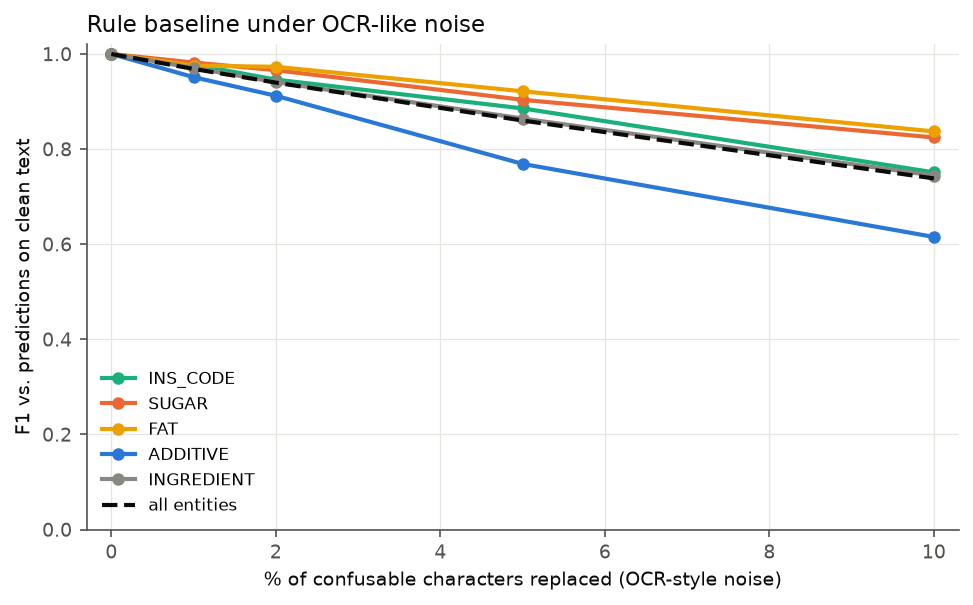

In [17]:
noise = show_json("reports/noise_robustness.json")
display(pd.DataFrame({rate: {"all": v["micro_f1"], **{k: v["per_class_f1"][k] for k in ("INS_CODE", "SUGAR", "FAT", "ADDITIVE")}}
                      for rate, v in noise.items()}).T.rename_axis("noise rate"))
display(Image("reports/figures/11_noise_robustness.png", width=650))

> **WHAT WE DID:** Packaged the rules as a baseline NER system and wrote one shared entity-level scorer (P/R/F1, micro, macro, per class, partial match). We also measured agreement with Open Food Facts' parser (F1 0.88) and robustness to OCR noise (F1 0.74 of clean output at 10% noise).
>
> **WHY:** Every model must be compared with the same scorer on the same gold test set. The noise experiment shows why a learned model is needed for OCR input.
>
> **INPUT:** Gold test records (after annotation), silver test split for the two sanity checks.
>
> **OUTPUT:** `reports/baseline_metrics.*` (after gold), `off_additive_agreement.json`, `noise_robustness.json`, figure 11.
>
> **HOW PERSON 2 USES IT:** He reports DistilBERT/BERT with `evaluate_tag_sequences` so the numbers are directly comparable to this baseline.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Entity-level F1 is stricter than token accuracy, where the many O tokens make every model look good. The baseline is only scored on human gold data, never on its own silver output."*

## 11. Error analysis

`src/evaluation/error_analysis.py` writes `reports/error_analysis/baseline_errors.csv` with columns
*text, expected entity, predicted entity, error type, entity category, tags* once gold exists.
Error types: false positive, false negative, boundary error, type error. Tags: INS-code variant,
OCR noise, compound ingredient, unknown term, overlapping category, ambiguous term.

In [18]:
from src.evaluation.error_analysis import compare_entities
if gold_test.exists():
    from src.evaluation.error_analysis import error_table, summarise
    errors = error_table(gold, predict_all(gold))
    display(summarise(errors))
    display(errors.head(20))
else:
    print("No gold test set yet - illustration on a hand-written example (NOT project data):")
    text = "organic cane sugar, citric acid, salt, Emulsifier (INS-471)"
    toy_gold = [{"start": 0, "end": 18, "label": "SUGAR", "text": "organic cane sugar"},
                {"start": 20, "end": 31, "label": "ADDITIVE", "text": "citric acid"},
                {"start": 33, "end": 37, "label": "INGREDIENT", "text": "salt"},
                {"start": 39, "end": 49, "label": "FUNCTION_CLASS", "text": "Emulsifier"},
                {"start": 51, "end": 58, "label": "INS_CODE", "text": "INS-471"}]
    toy_pred = [{"start": 8, "end": 18, "label": "SUGAR", "text": "cane sugar"},
                {"start": 20, "end": 31, "label": "INGREDIENT", "text": "citric acid"},
                {"start": 39, "end": 49, "label": "FUNCTION_CLASS", "text": "Emulsifier"}]
    display(pd.DataFrame(compare_entities(text, toy_gold, toy_pred)))

No gold test set yet - illustration on a hand-written example (NOT project data):


,text,expected_entity,expected_label,predicted_entity,predicted_label,error_type,entity_category,tags
0,"organic cane sugar, citric acid, salt, Emulsifier (INS-471",organic cane sugar,SUGAR,cane sugar,SUGAR,boundary_error,SUGAR,
1,"organic cane sugar, citric acid, salt, Emulsifier (INS-471)",citric acid,ADDITIVE,citric acid,INGREDIENT,type_error,ADDITIVE,ambiguous_term
2,"organic cane sugar, citric acid, salt, Emulsifier (INS-471)",salt,INGREDIENT,,,false_negative,INGREDIENT,unknown_term
3,"e sugar, citric acid, salt, Emulsifier (INS-471)",INS-471,INS_CODE,,,false_negative,INS_CODE,ins_code_variant|compound|unknown_term


> **WHAT WE DID:** Built an error analysis that classifies every disagreement between gold and prediction and tags the likely cause.
>
> **WHY:** A single F1 number does not tell us what to fix. Error categories are what we discuss as limitations in the presentation.
>
> **INPUT:** Gold records + baseline predictions.
>
> **OUTPUT:** `reports/error_analysis/baseline_errors.csv` and `baseline_error_summary.json` (after gold).
>
> **HOW PERSON 2 USES IT:** `compare_entities` works for his model predictions too, so the error categories are comparable.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"We separate boundary errors from type errors and missed entities, and tag causes such as OCR noise or INS-code notation."*

## 12. Integration

### Person 2: Hugging Face `datasets`

In [19]:
import datasets
from datasets import Dataset, DatasetDict, Sequence, ClassLabel
datasets.disable_progress_bars()
id2label = {int(k): v for k, v in json.load(open("data/splits/id2label.json")).items()}
names = [id2label[i] for i in range(len(id2label))]
ds = DatasetDict({s: Dataset.from_json(f"data/splits/silver/{s}.jsonl.gz") for s in ("train", "validation", "test")})
ds = ds.cast_column("ner_tags", Sequence(ClassLabel(names=names)))
print(ds)
row = next(r for r in ds["validation"] if 13 in r["ner_tags"] and len(r["tokens"]) < 40)   # 13 = B-INS_CODE
pd.DataFrame({"token": row["tokens"], "ner_tag (id)": row["ner_tags"], "ner_tag": [names[t] for t in row["ner_tags"]]}).T

DatasetDict({
    train: Dataset({
        features: ['id', 'product_id', 'country_group', 'split', 'text', 'tokens', 'ner_tags', 'ner_tag_names', 'token_offsets', 'entities', 'label_source'],
        num_rows: 15556
    })
    validation: Dataset({
        features: ['id', 'product_id', 'country_group', 'split', 'text', 'tokens', 'ner_tags', 'ner_tag_names', 'token_offsets', 'entities', 'label_source'],
        num_rows: 3280
    })
    test: Dataset({
        features: ['id', 'product_id', 'country_group', 'split', 'text', 'tokens', 'ner_tags', 'ner_tag_names', 'token_offsets', 'entities', 'label_source'],
        num_rows: 3487
    })
})


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
token,Poblano,pepper,",",water,",",salt,",",citric,acid,(,...,sugar,and,Calcium,chloride,(,E509,),.,carbono,)
ner_tag (id),19,20,0,19,0,19,0,11,12,0,...,1,0,11,12,0,13,0,0,0,0
ner_tag,B-INGREDIENT,I-INGREDIENT,O,B-INGREDIENT,O,B-INGREDIENT,O,B-ADDITIVE,I-ADDITIVE,O,...,B-SUGAR,O,B-ADDITIVE,I-ADDITIVE,O,B-INS_CODE,O,O,O,O


### Person 3: OCR text → preprocessing → entities → interpretation

In [20]:
ocr_output = "INGREDIENTS: Refined Wheat Flour (Maida), Sugar, Edible Vegetable Oil (Palm), lnvert Syrup,\nRaising Agents (503(ii), 500(ii)), Emulsifier (INS 322), Colour (150d). CONTAINS WHEAT, MILK."
result = DictionaryNER().predict(ocr_output)
display(highlight(result["text"], result["entities"]))
for e in interpret_entities(result["text"], result["entities"]):
    if e["label"] != "FUNCTION_CLASS":
        print(f"{e['label']:14} {describe(e)}")

INGREDIENT     Refined Wheat Flour
INGREDIENT     Maida
SUGAR          Sugar -> sugar
FAT            Edible Vegetable Oil -> fat
INGREDIENT     Palm
SUGAR          lnvert Syrup -> sugar
INS_CODE       503(ii) -> Ammonium hydrogen carbonate -> raising agent
INS_CODE       500(ii) -> Sodium hydrogen carbonate -> raising agent
INS_CODE       INS 322 -> Lecithins -> emulsifier
INS_CODE       150d -> Sulphite ammonia caramel -> colour


Note `lnvert Syrup` (OCR read "I" as "l"): the head-word rule still finds a SUGAR, but an exact dictionary
lookup would have failed. That is the kind of robustness we expect the Transformer to improve.

> **WHAT WE DID:** Delivered Hugging Face-ready split files with label2id/id2label and a dataset card, and a single preprocessing + labelling entry point that accepts OCR text.
>
> **WHY:** The three modules must plug together without re-implementing anything.
>
> **INPUT:** Our processed data and functions.
>
> **OUTPUT:** `data/splits/` (+ `README.md` dataset card) and `process_ingredient_text`, `DictionaryNER`, `interpret_entities`.
>
> **HOW PERSON 2 USES IT:** `Dataset.from_json` loads the files directly, with integer `ner_tags` and the 21 label names.
>
> **HOW TO EXPLAIN IT IN THE VIVA:** *"Our module exposes stable interfaces: files for Person 2, and functions for Person 3 that do not depend on Open Food Facts."*

## 13. Final processed CSV

`src/data/export_processed.py` → `data/processed/ingredients_processed.csv` (one row per product)

In [21]:
final = pd.read_csv("data/processed/ingredients_processed.csv", dtype={"product_id": str})
print(final.shape)
print(list(final.columns))
cols = ["product_name", "country_group", "split", "ingredients_text_normalized", "sugars", "fats", "preservatives",
        "colours", "ins_numbers", "additive_interpretations"]
final[final["n_INS_CODE"] > 2][cols].sample(4, random_state=1)

(22323, 33)
['product_id', 'product_name', 'brands', 'country_group', 'main_category', 'split', 'ingredients_text_raw', 'ingredients_text_normalized', 'n_tokens', 'n_entities', 'sugars', 'sweeteners', 'fats', 'preservatives', 'colours', 'additives', 'ins_codes', 'function_classes', 'flavourings', 'other_ingredients', 'ins_numbers', 'additive_interpretations', 'n_SUGAR', 'n_SWEETENER', 'n_FAT', 'n_PRESERVATIVE', 'n_COLOUR', 'n_ADDITIVE', 'n_INS_CODE', 'n_FUNCTION_CLASS', 'n_FLAVOURING', 'n_INGREDIENT', 'label_source']


,product_name,country_group,split,ingredients_text_normalized,sugars,fats,preservatives,colours,ins_numbers,additive_interpretations
15993,NaN,india,train,"Refined Soybean Oil (Fortified with Vitamin A & D), Water, Sugar, Thickeners-E 1442, E 1450, Natural Vinegar, lodise...",Sugar,Refined Soybean Oil,NaN,NaN,1442 | 1450 | 202 | 385,"E 1442 -> Hydroxypropyl distarch phosphate -> emulsifier, stabiliser | E 1450 -> Starch sodium octenyl succinate -> ..."
78,Threptin,india,train,"Casein, Sucrose, Precooked Rice Flour, Edible Vegetable Fat, Bengal Gram, Raising Agent [500 (ii)], Natural Colour (...",Sucrose,Edible Vegetable Fat,NaN,NaN,500ii | 150 | 525 | 304,500 (ii) -> Sodium hydrogen carbonate -> raising agent | 150 -> Caramel -> colour | 525 -> Potassium hydroxide -> ac...
4970,NaN,other_english,train,"PENE SAFETY EAL OUR ACK gns Serving suggestion: A great flavour base for your pizza or pasta sauce, this Mediterrane...",NaN,vegetable oil,NaN,NaN,260 | 330 | 415 | 223,260 -> Acetic acid -> acidity regulator | 330 -> Citric acid -> acidity regulator | 415 -> Xanthan gum -> thickener ...
21646,Large Thai Red Chicken Curry,other_english,validation,"Brown Rice (44%), Chicken Breast (29%), Red Curry Sauce (27%) [Coconut Cream (Coconut Cream, Water, Stablisers (412....",NaN,NaN,NaN,NaN,415 | 223 | 270,415 -> Xanthan gum -> stabiliser | 223 -> Sodium metabisulphite -> preservative | 270 -> Lactic acid -> acid


In [22]:
entities_csv = pd.read_csv("data/processed/silver_entities.csv.gz", dtype={"product_id": str, "ins_number": str})
print(entities_csv.shape)
entities_csv[entities_csv["label"] == "INS_CODE"].sample(6, random_state=0)[
    ["text", "label", "rule", "ins_number", "linked_name", "declared_class", "interpretation"]]

(357934, 13)


,text,label,rule,ins_number,linked_name,declared_class,interpretation
72519,Ins 150A,INS_CODE,regex:ins_code_INS,150a,Plain caramel,NaN,Ins 150A -> Plain caramel -> colour
279291,471,INS_CODE,regex:ins_code_bare,471,Mono- and diglycerides of fatty acids,emulsifier,471 -> Mono- and diglycerides of fatty acids -> emulsifier
304728,INS 110,INS_CODE,regex:ins_code_INS,110,Sunset yellow FCF,colour,INS 110 -> Sunset yellow FCF -> colour
284875,122,INS_CODE,regex:ins_code_bare,122,Azorubine,colour,122 -> Azorubine -> colour
302843,INS 334,INS_CODE,regex:ins_code_INS,334,L(+)-tartaric acid,acidity-regulator,INS 334 -> L(+)-tartaric acid -> acidity regulator
313959,INS 1100,INS_CODE,regex:ins_code_INS,1100,Alpha-Amylase,flour-treatment-agent,INS 1100 -> Alpha-Amylase -> flour treatment agent


## 14. Limitations (for the report and the viva)

* **Silver labels are noisy.** INGREDIENT (59% of entities) comes from a fallback rule; rare words are left
  unlabelled to keep OCR garbage out, which lowers recall for rare ingredients.
* **No gold numbers yet.** Baseline P/R/F1 and the error analysis need the human-verified gold test set.
* **Source noise.** Open Food Facts text is crowd-sourced and often OCR-ed ("lodized salt", "Milk Solrds").
  This is realistic for our use-case, but it also enters the silver labels.
* **English only.** A keyword language heuristic. Bilingual EN/FR labels are removed, and lists that are mostly
  non-Latin script are skipped.
* **Reference functional classes are incomplete** (e.g. lactic acid has none in OFF). The *declared* class on the label
  is preferred when it exists.
* **Dictionary coverage.** Unseen spellings and missing commas break exact matching. Under 10% OCR-like noise the
  baseline keeps only F1 0.74 of its clean output.
* **Interpretation is not a health assessment.** The system explains what an ingredient is and what it is used for;
  it makes no health claims.